# **Inference & Carbon Stock Estimation — Bukit Jaas LULC**

Tujuan: prediksi kelas LULC untuk 11.373 pixel raw → estimasi carbon stock & nilai ekonomi.

Pipeline:
```
raw_bukit_jaas_750_2024.csv
    → [RF model.pkl]     → predicted_class, confidence
    → [carbon_lookup.py] → carbon_stock, co2_equivalent, economic_value
    → data/output/predictions_lulc.csv
    → data/output/carbon_stock_map.csv
```

In [ ]:
# CONFIG 
raw_data_path   = "../data/raw/raw_bukit_jaas_750_2024.csv"
experiment_name = "01_random_forest"
run_id          = "YYYYMMDD_HHMM"
model_path      = "../models/01_random_forest/20260524_0122/model.pkl"
config_path     = "../models/01_random_forest/20260524_0122/config.json"
output_path     = "../data/output/"

print(f"Model path : {model_path}")
print(f"Config path: {config_path}")

Model path : ../models/01_random_forest/20260524_0122/model.pkl
Config path: ../models/01_random_forest/20260524_0122/config.json


## **Load Model & Config**

In [3]:
import sys
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from sklearn.metrics import confusion_matrix, classification_report

sys.path.append("..")
from src.carbon_lookup import (
    CARBON_STOCK_PER_HA,
    PIXEL_AREA_HA,
    CO2_CONVERSION_RATIO,
    CARBON_PRICE_USD,
    get_carbon_stock_per_ha,
    calculate_co2_equivalent_ton,
    calculate_economic_value_usd
)

In [4]:
trained_rf_model = joblib.load(model_path)

with open(config_path, "r") as config_file:
    model_config = json.load(config_file)

features_used  = model_config["features_used"]
trained_classes = model_config["classes"]

print(f"Experiment   : {model_config['experiment_name']}")
print(f"Run ID       : {model_config['run_id']}")
print(f"Trained date : {model_config['trained_date']}")
print(f"Test accuracy: {model_config['test_accuracy']}")
print(f"Kappa score  : {model_config['kappa_score']}")
print(f"Features     : {features_used}")

Experiment   : 01_random_forest
Run ID       : 20260524_0122
Trained date : 2026-05-24 01:23
Test accuracy: 0.809524
Kappa score  : 0.75
Features     : ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'EVI', 'SAVI', 'NBR', 'ETH_CanopyHeight', 'Elevation', 'Slope', 'Aspect']


---
# **Load & Validasi Data**

In [5]:
raw_pixel_dataframe = pd.read_csv(raw_data_path)

print(f"Raw data shape: {raw_pixel_dataframe.shape}")
raw_pixel_dataframe.head()

Raw data shape: (11373, 16)


,longitude,latitude,B2,B3,B4,B8,B11,B12,NDVI,EVI,SAVI,NBR,ETH_CanopyHeight,Elevation,Slope,Aspect
0,111.695220,-8.056226,846.0,1032.0,940.0,2205.0,2183.0,1607.0,0.402226,2.106929,0.603243,0.156873,19.0,118,11.0,194.0
1,111.695310,-8.056226,954.0,1070.0,816.0,2351.0,2183.0,1607.0,0.484686,41.263441,0.726914,0.187974,19.0,118,11.0,194.0
2,111.695400,-8.056226,904.0,987.0,794.0,2482.0,2319.0,1537.0,0.515263,9.036403,0.772776,0.235133,20.0,118,12.0,194.0
3,111.695489,-8.056226,876.0,940.0,684.0,2513.0,2319.0,1537.0,0.572099,95.260417,0.858014,0.240988,20.0,119,13.0,195.0
4,111.695579,-8.056226,944.0,1068.0,854.0,2966.0,2449.0,1654.0,0.552880,5.222552,0.829211,0.283983,21.0,119,14.0,194.0


In [6]:
missing_features = [f for f in features_used if f not in raw_pixel_dataframe.columns]
extra_features   = [f for f in raw_pixel_dataframe.columns if f not in features_used and f not in ["longitude", "latitude"]]

print(f"Features expected: {len(features_used)}")
print(f"Missing in raw   : {missing_features if missing_features else 'None'}")
print(f"Extra in raw     : {extra_features if extra_features else 'None'}")

assert len(missing_features) == 0, f"Missing features in raw data: {missing_features}"

Features expected: 14
Missing in raw   : None
Extra in raw     : None


In [7]:
missing_counts = raw_pixel_dataframe[features_used].isnull().sum()
print("Missing values per feature:")
print(missing_counts[missing_counts > 0] if missing_counts.any() else "None")

Missing values per feature:
ETH_CanopyHeight      1
Slope               165
Aspect              165
dtype: int64


---
# **Prediksi LULC**

In [8]:
raw_feature_matrix     = raw_pixel_dataframe[features_used]
predicted_class_array  = trained_rf_model.predict(raw_feature_matrix)
predicted_proba_matrix = trained_rf_model.predict_proba(raw_feature_matrix)
confidence_scores      = predicted_proba_matrix.max(axis=1)

print(f"Predicted {len(predicted_class_array)} pixels")
print("\nPredicted class distribution:")
predicted_series = pd.Series(predicted_class_array, name="predicted_class")
print(predicted_series.value_counts().to_string())

Predicted 11373 pixels

Predicted class distribution:
predicted_class
Secondary_Forest    6937
Primary_Forest      2019
Estate_Crop         1526
Bare_Ground          518
Paddy_Field          199
Settlement           174


In [9]:
# Open_Water tidak ada di training data — flag jika muncul di prediksi
open_water_count = (predicted_series == "Open_Water").sum()
if open_water_count > 0:
    print(f"WARNING: {open_water_count} pixel diprediksi sebagai Open_Water (anomali — tidak ada di training data)")
else:
    print("Open_Water check: OK (tidak ada prediksi Open_Water)")

Open_Water check: OK (tidak ada prediksi Open_Water)


In [10]:
prediction_dataframe = raw_pixel_dataframe[["longitude", "latitude"]].copy()
prediction_dataframe["predicted_class"] = predicted_class_array
prediction_dataframe["confidence"]      = confidence_scores.round(4)

os.makedirs(output_path, exist_ok=True)
predictions_output_path = output_path + "predictions_lulc.csv"
prediction_dataframe.to_csv(predictions_output_path, index=False)

print(f"Saved: {predictions_output_path}")
prediction_dataframe.head()

Saved: ../data/output/predictions_lulc.csv


,longitude,latitude,predicted_class,confidence
0,111.695220,-8.056226,Estate_Crop,0.3137
1,111.695310,-8.056226,Estate_Crop,0.3226
2,111.695400,-8.056226,Secondary_Forest,0.3729
3,111.695489,-8.056226,Secondary_Forest,0.4564
4,111.695579,-8.056226,Estate_Crop,0.4517


---
# **Sanity Check**

Ambil pixel yang koordinatnya ada di training data → bandingkan prediksi vs label asli.
Ini adalah in-sample check, bukan evaluasi generalisasi.

In [11]:
labeled_dataframe = pd.read_csv("../data/labeled/labeled_data_manual_sampling.csv")

In [12]:
prediction_dataframe["coord_key"] = (
    prediction_dataframe["longitude"].round(8).astype(str) + "_" +
    prediction_dataframe["latitude"].round(8).astype(str)
)
labeled_dataframe["coord_key"] = (
    labeled_dataframe["longitude"].round(8).astype(str) + "_" +
    labeled_dataframe["latitude"].round(8).astype(str)
)

sanity_check_dataframe = prediction_dataframe.merge(
    labeled_dataframe[["coord_key", "Class"]],
    on="coord_key", how="inner"
).rename(columns={"Class": "true_class"})

print(f"Sanity check pixels matched: {len(sanity_check_dataframe)} / {len(labeled_dataframe)}")

Sanity check pixels matched: 207 / 207


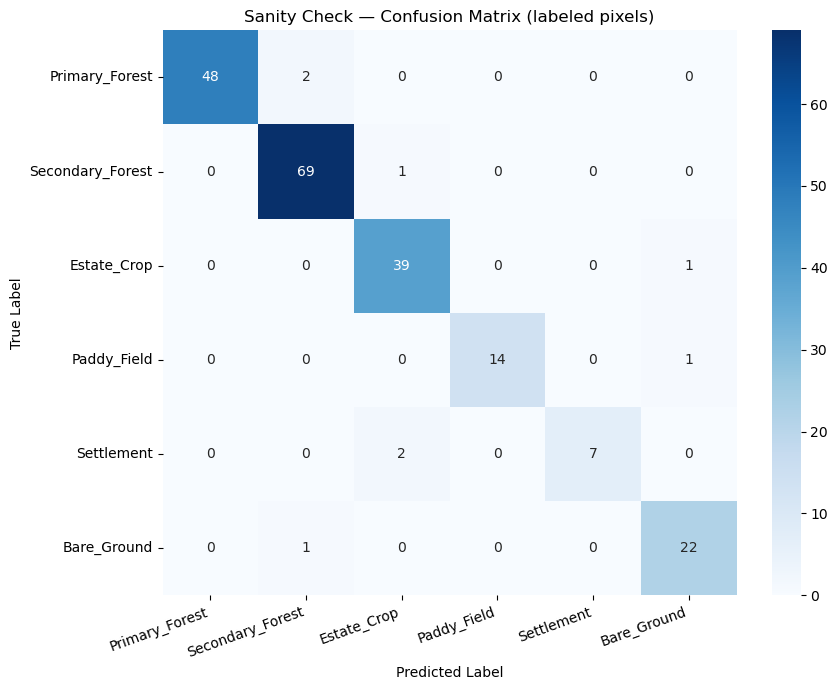

                  precision    recall  f1-score   support

  Primary_Forest       1.00      0.96      0.98        50
Secondary_Forest       0.96      0.99      0.97        70
     Estate_Crop       0.93      0.97      0.95        40
     Paddy_Field       1.00      0.93      0.97        15
      Settlement       1.00      0.78      0.88         9
     Bare_Ground       0.92      0.96      0.94        23

        accuracy                           0.96       207
       macro avg       0.97      0.93      0.95       207
    weighted avg       0.96      0.96      0.96       207



In [13]:
lulc_class_order = [
    "Primary_Forest", "Secondary_Forest", "Estate_Crop",
    "Paddy_Field", "Settlement", "Bare_Ground"
]

sanity_confusion = confusion_matrix(
    sanity_check_dataframe["true_class"],
    sanity_check_dataframe["predicted_class"],
    labels=lulc_class_order
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    sanity_confusion,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=lulc_class_order,
    yticklabels=lulc_class_order,
    ax=ax
)
ax.set_title("Sanity Check — Confusion Matrix (labeled pixels)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print(classification_report(
    sanity_check_dataframe["true_class"],
    sanity_check_dataframe["predicted_class"],
    labels=lulc_class_order
))

---
# **Carbon Stock Estimation**

Konversi prediksi LULC → carbon stock → CO2 equivalent → nilai ekonomi.
Semua konstanta dari `src/carbon_lookup.py` (MoEF 2022, Table 9).

In [14]:
print("Carbon Stock Lookup Table (ton C/ha):")
for lulc_class, value in CARBON_STOCK_PER_HA.items():
    print(f"  {lulc_class:<20}: {value}")

print(f"\nPixel area          : {PIXEL_AREA_HA} ha")
print(f"CO2 conversion ratio: {CO2_CONVERSION_RATIO:.4f} (44/12)")
print(f"Carbon price        : USD {CARBON_PRICE_USD}/ton CO2")

Carbon Stock Lookup Table (ton C/ha):
  Primary_Forest      : 210.92
  Secondary_Forest    : 127.18
  Estate_Crop         : 63.73
  Paddy_Field         : 12.35
  Settlement          : 2.79
  Bare_Ground         : 2.96
  Open_Water          : 0.0

Pixel area          : 0.01 ha
CO2 conversion ratio: 3.6667 (44/12)
Carbon price        : USD 25.0/ton CO2


In [15]:
carbon_stock_dataframe = prediction_dataframe[["longitude", "latitude", "predicted_class", "confidence"]].copy()

carbon_stock_dataframe["carbon_stock_ton_per_ha"] = (
    carbon_stock_dataframe["predicted_class"]
    .map(CARBON_STOCK_PER_HA)
)

carbon_stock_dataframe["carbon_total_ton"] = (
    carbon_stock_dataframe["carbon_stock_ton_per_ha"] * PIXEL_AREA_HA
)

carbon_stock_dataframe["co2_equivalent_ton"] = (
    carbon_stock_dataframe["carbon_total_ton"] * CO2_CONVERSION_RATIO
)

carbon_stock_dataframe["economic_value_usd"] = (
    carbon_stock_dataframe["co2_equivalent_ton"] * CARBON_PRICE_USD
)

carbon_output_path = output_path + "carbon_stock_map.csv"
carbon_stock_dataframe.to_csv(carbon_output_path, index=False)

print(f"Saved: {carbon_output_path}")
carbon_stock_dataframe.head()

Saved: ../data/output/carbon_stock_map.csv


,longitude,latitude,predicted_class,confidence,carbon_stock_ton_per_ha,carbon_total_ton,co2_equivalent_ton,economic_value_usd
0,111.695220,-8.056226,Estate_Crop,0.3137,63.73,0.6373,2.336767,58.419167
1,111.695310,-8.056226,Estate_Crop,0.3226,63.73,0.6373,2.336767,58.419167
2,111.695400,-8.056226,Secondary_Forest,0.3729,127.18,1.2718,4.663267,116.581667
3,111.695489,-8.056226,Secondary_Forest,0.4564,127.18,1.2718,4.663267,116.581667
4,111.695579,-8.056226,Estate_Crop,0.4517,63.73,0.6373,2.336767,58.419167


In [16]:
carbon_summary = carbon_stock_dataframe.groupby("predicted_class").agg(
    pixel_count         = ("predicted_class", "count"),
    area_ha             = ("carbon_total_ton", "count"),
    total_carbon_ton    = ("carbon_total_ton", "sum"),
    total_co2_ton       = ("co2_equivalent_ton", "sum"),
    total_value_usd     = ("economic_value_usd", "sum")
).reset_index()

carbon_summary["area_ha"] = carbon_summary["pixel_count"] * PIXEL_AREA_HA

total_row = pd.DataFrame([{
    "predicted_class"   : "TOTAL",
    "pixel_count"       : carbon_summary["pixel_count"].sum(),
    "area_ha"           : carbon_summary["area_ha"].sum(),
    "total_carbon_ton"  : carbon_summary["total_carbon_ton"].sum(),
    "total_co2_ton"     : carbon_summary["total_co2_ton"].sum(),
    "total_value_usd"   : carbon_summary["total_value_usd"].sum()
}])

carbon_summary_full = pd.concat([carbon_summary, total_row], ignore_index=True)

pd.options.display.float_format = "{:,.2f}".format
print("Carbon Stock Summary per LULC Class:")
carbon_summary_full

Carbon Stock Summary per LULC Class:


,predicted_class,pixel_count,area_ha,total_carbon_ton,total_co2_ton,total_value_usd
0,Bare_Ground,518,5.18,15.33,56.22,"1,405.51"
1,Estate_Crop,1526,15.26,972.52,"3,565.91","89,147.65"
2,Paddy_Field,199,1.99,24.58,90.11,"2,252.85"
3,Primary_Forest,2019,20.19,"4,258.47","15,614.41","390,360.19"
4,Secondary_Forest,6937,69.37,"8,822.48","32,349.08","808,727.02"
5,Settlement,174,1.74,4.85,17.80,445.00
6,TOTAL,11373,113.73,"14,098.24","51,693.53","1,292,338.22"


---
# **Visualisasi — GeoPandas**

In [17]:
carbon_geodataframe = gpd.GeoDataFrame(
    carbon_stock_dataframe,
    geometry=gpd.points_from_xy(
        carbon_stock_dataframe["longitude"],
        carbon_stock_dataframe["latitude"]
    ),
    crs="EPSG:4326"
)
print("GeoDataFrame CRS:", carbon_geodataframe.crs)

GeoDataFrame CRS: EPSG:4326


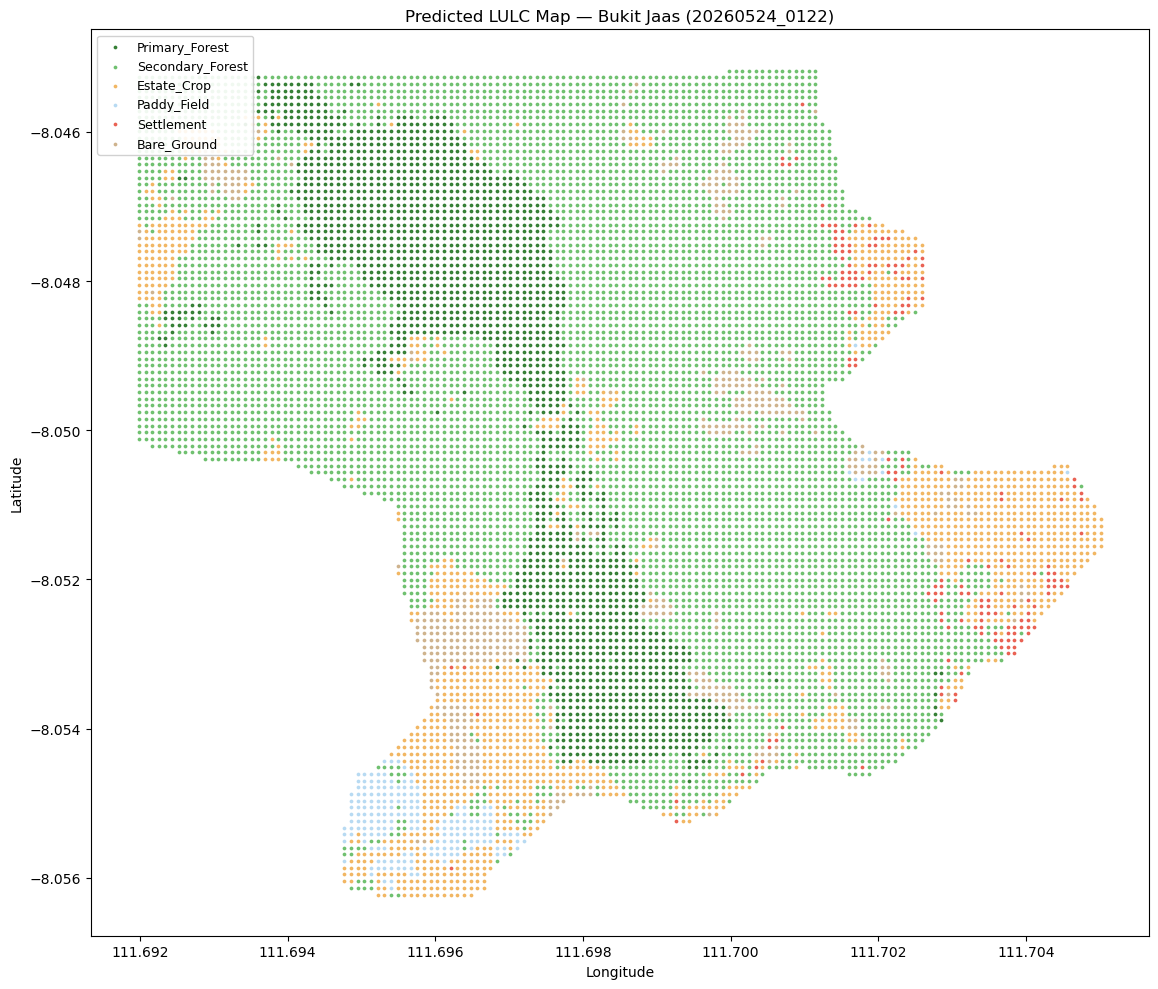

In [18]:
lulc_class_colors = {
    "Primary_Forest"   : "#1a6e1a",
    "Secondary_Forest" : "#5cb85c",
    "Estate_Crop"      : "#f0ad4e",
    "Paddy_Field"      : "#aed6f1",
    "Settlement"       : "#e74c3c",
    "Bare_Ground"      : "#c8a97e",
}

fig, ax = plt.subplots(figsize=(12, 10))

for lulc_class, color in lulc_class_colors.items():
    subset = carbon_geodataframe[carbon_geodataframe["predicted_class"] == lulc_class]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, markersize=3, label=lulc_class, alpha=0.8)

ax.set_title(f"Predicted LULC Map — Bukit Jaas ({model_config['run_id']})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

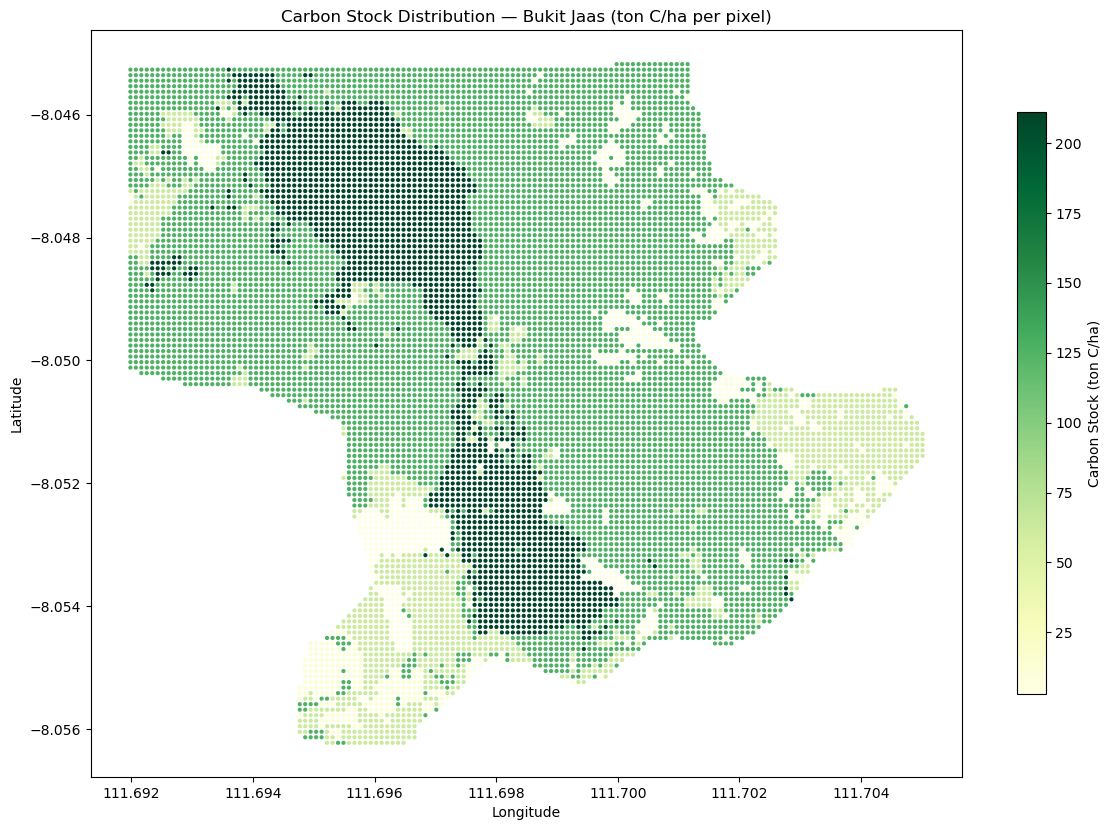

In [19]:
fig, ax = plt.subplots(figsize=(12, 10))

carbon_geodataframe.plot(
    column="carbon_stock_ton_per_ha",
    cmap="YlGn",
    markersize=4,
    legend=True,
    legend_kwds={"label": "Carbon Stock (ton C/ha)", "shrink": 0.6},
    ax=ax
)
ax.set_title("Carbon Stock Distribution — Bukit Jaas (ton C/ha per pixel)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

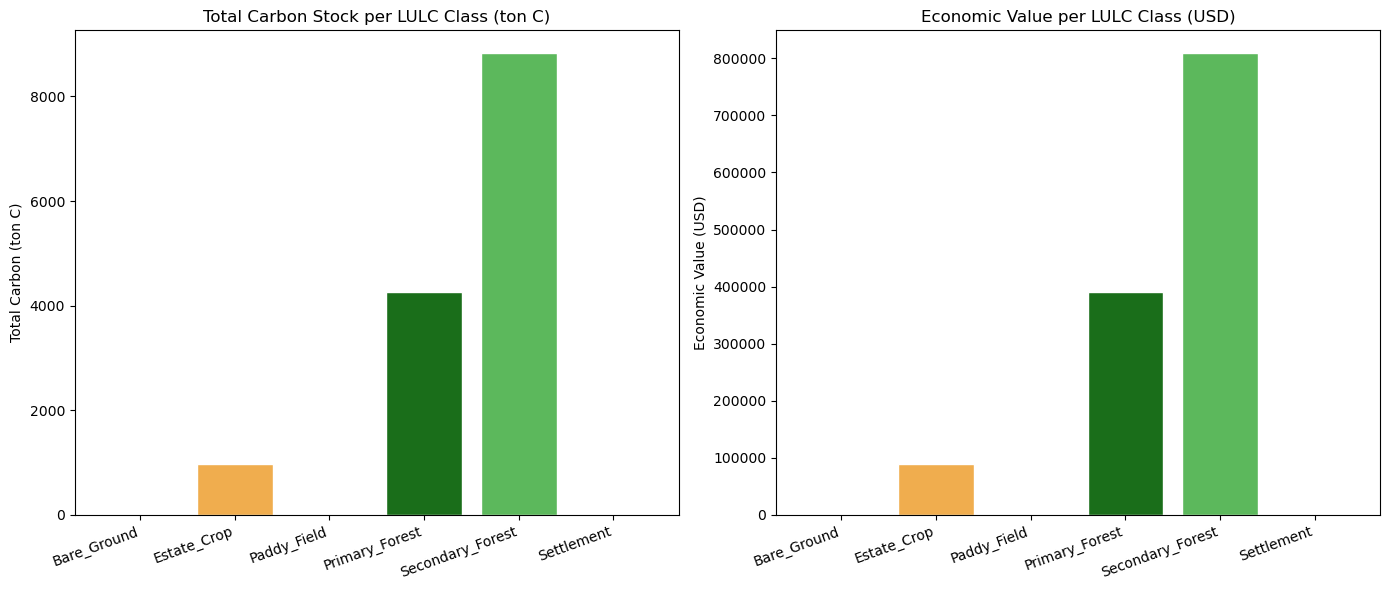

In [20]:
summary_no_total = carbon_summary.set_index("predicted_class")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bar_colors = [lulc_class_colors.get(cls, "#999") for cls in summary_no_total.index]

axes[0].bar(summary_no_total.index, summary_no_total["total_carbon_ton"],
            color=bar_colors, edgecolor="white")
axes[0].set_title("Total Carbon Stock per LULC Class (ton C)")
axes[0].set_ylabel("Total Carbon (ton C)")
axes[0].set_xlabel("")
plt.setp(axes[0].get_xticklabels(), rotation=20, ha="right")

axes[1].bar(summary_no_total.index, summary_no_total["total_value_usd"],
            color=bar_colors, edgecolor="white")
axes[1].set_title("Economic Value per LULC Class (USD)")
axes[1].set_ylabel("Economic Value (USD)")
axes[1].set_xlabel("")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.show()

In [21]:
total_carbon_ton   = carbon_stock_dataframe["carbon_total_ton"].sum()
total_co2_ton      = carbon_stock_dataframe["co2_equivalent_ton"].sum()
total_value_usd    = carbon_stock_dataframe["economic_value_usd"].sum()
total_area_ha      = len(carbon_stock_dataframe) * PIXEL_AREA_HA

print("=" * 50)
print("RINGKASAN TOTAL — BUKIT JAAS")
print("=" * 50)
print(f"Total pixels         : {len(carbon_stock_dataframe):,}")
print(f"Total area           : {total_area_ha:,.2f} ha")
print(f"Total carbon stock   : {total_carbon_ton:,.2f} ton C")
print(f"Total CO2 equivalent : {total_co2_ton:,.2f} ton CO2")
print(f"Total economic value : USD {total_value_usd:,.2f}")
print("=" * 50)

RINGKASAN TOTAL — BUKIT JAAS
Total pixels         : 11,373
Total area           : 113.73 ha
Total carbon stock   : 14,098.24 ton C
Total CO2 equivalent : 51,693.53 ton CO2
Total economic value : USD 1,292,338.22
